In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# For reading stock data from yahoo

import yfinance as yf


# For time stamps
from datetime import datetime


# The tech stocks we'll use for this analysis
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

# Set up End and Start times for data grab
end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

stocks_dict = {}
for stock in tech_list:
    df = yf.download(stock, start, end, auto_adjust=False)
    # Drop the redundant ticker level
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    stocks_dict[stock] = df

# Access via: stocks_dict['AAPL']
    

company_list = [stocks_dict['AAPL'], stocks_dict['GOOG'], stocks_dict['MSFT'], stocks_dict['AMZN']]
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

for company, com_name in zip(company_list, company_name):
    company["company_name"] = com_name
    
df = pd.concat(company_list, axis=0)
df.tail(10)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume,company_name
Date,,,,,,,
2026-03-10,214.330002,214.330002,215.649994,212.429993,214.190002,35678800,AMAZON
2026-03-11,212.649994,212.649994,217.000000,211.350006,215.710007,34199300,AMAZON
2026-03-12,209.529999,209.529999,211.710007,208.149994,210.389999,44349500,AMAZON
2026-03-13,207.669998,207.669998,210.559998,206.220001,209.610001,35662100,AMAZON
2026-03-16,211.740005,211.740005,212.720001,207.449997,208.350006,42209300,AMAZON
2026-03-17,215.199997,215.199997,215.699997,212.429993,212.820007,44969900,AMAZON
2026-03-18,209.869995,209.869995,215.139999,208.830002,213.929993,37846600,AMAZON
2026-03-19,208.759995,208.759995,209.119995,206.050003,207.059998,36440600,AMAZON
2026-03-20,205.369995,205.369995,207.539993,204.320007,207.399994,63694600,AMAZON


In [2]:
stocks_dict['AAPL'].describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,238.024636,238.480916,241.015379,235.930318,238.362589,5.296913e+07
std,29.121375,28.919007,28.810223,29.069863,29.067433,2.342090e+07
min,171.671799,172.419998,190.339996,169.210007,171.949997,1.791060e+07
25%,209.452614,210.150002,212.185005,207.930000,210.050003,3.952930e+07
50%,245.032959,245.500000,248.850006,243.419998,246.600006,4.674240e+07
75%,264.264999,264.264999,267.184998,261.625000,263.544998,5.581925e+07
max,285.922455,286.190002,288.619995,283.299988,286.200012,1.843959e+08


In [3]:
stocks_dict['GOOG'].describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,240.618380,240.990438,243.785048,237.813821,240.740195,2.406259e+07
std,63.694632,63.579996,64.258178,62.778152,63.633830,1.029139e+07
min,146.075027,146.580002,151.059998,142.660004,143.389999,6.138200e+06
25%,176.702003,177.099998,178.293999,174.290001,176.327499,1.787850e+07
50%,245.127274,245.460007,247.149994,241.177994,244.839996,2.165440e+07
75%,306.222153,306.329987,309.069992,302.375000,305.337494,2.611550e+07
max,344.657196,344.899994,350.149994,338.589996,348.515015,7.872980e+07


In [4]:
stocks_dict['MSFT'].describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,465.324843,467.320279,471.394581,463.132032,467.492729,2.499882e+07
std,48.928693,49.185055,48.877249,49.788733,49.648595,1.252662e+07
min,351.866241,354.559998,364.480011,344.790009,350.880005,5.855900e+06
25%,425.858002,427.845001,437.360001,423.574997,431.424988,1.679275e+07
50%,479.744995,480.839996,484.250000,476.339996,481.239990,2.157890e+07
75%,506.105453,508.210007,511.635010,504.699997,508.555008,2.852575e+07
max,539.825256,542.070007,555.450012,540.770020,555.229980,1.288553e+08


In [5]:
stocks_dict['AMZN'].describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,218.279124,218.279124,220.773387,215.640040,218.300678,4.697593e+07
std,17.271081,17.271081,17.089560,17.812050,17.776028,2.182907e+07
min,167.320007,167.320007,169.600006,161.380005,162.000000,1.142050e+07
25%,208.599998,208.599998,210.805000,205.275002,208.225006,3.477100e+07
50%,221.470001,221.470001,223.500000,219.119995,221.820007,4.141060e+07
75%,230.575005,230.575005,232.464996,228.505005,230.725006,5.148065e+07
max,254.000000,254.000000,258.600006,252.899994,255.360001,1.792109e+08


In [6]:
stocks_dict['AAPL'].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-24 to 2026-03-23
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Adj Close     251 non-null    float64
 1   Close         251 non-null    float64
 2   High          251 non-null    float64
 3   Low           251 non-null    float64
 4   Open          251 non-null    float64
 5   Volume        251 non-null    int64  
 6   company_name  251 non-null    str    
dtypes: float64(5), int64(1), str(1)
memory usage: 15.7 KB


In [7]:
stocks_dict['GOOG'].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-24 to 2026-03-23
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Adj Close     251 non-null    float64
 1   Close         251 non-null    float64
 2   High          251 non-null    float64
 3   Low           251 non-null    float64
 4   Open          251 non-null    float64
 5   Volume        251 non-null    int64  
 6   company_name  251 non-null    str    
dtypes: float64(5), int64(1), str(1)
memory usage: 15.7 KB


In [8]:
stocks_dict['MSFT'].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-24 to 2026-03-23
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Adj Close     251 non-null    float64
 1   Close         251 non-null    float64
 2   High          251 non-null    float64
 3   Low           251 non-null    float64
 4   Open          251 non-null    float64
 5   Volume        251 non-null    int64  
 6   company_name  251 non-null    str    
dtypes: float64(5), int64(1), str(1)
memory usage: 15.7 KB


In [9]:
stocks_dict['AMZN'].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-24 to 2026-03-23
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Adj Close     251 non-null    float64
 1   Close         251 non-null    float64
 2   High          251 non-null    float64
 3   Low           251 non-null    float64
 4   Open          251 non-null    float64
 5   Volume        251 non-null    int64  
 6   company_name  251 non-null    str    
dtypes: float64(5), int64(1), str(1)
memory usage: 15.7 KB


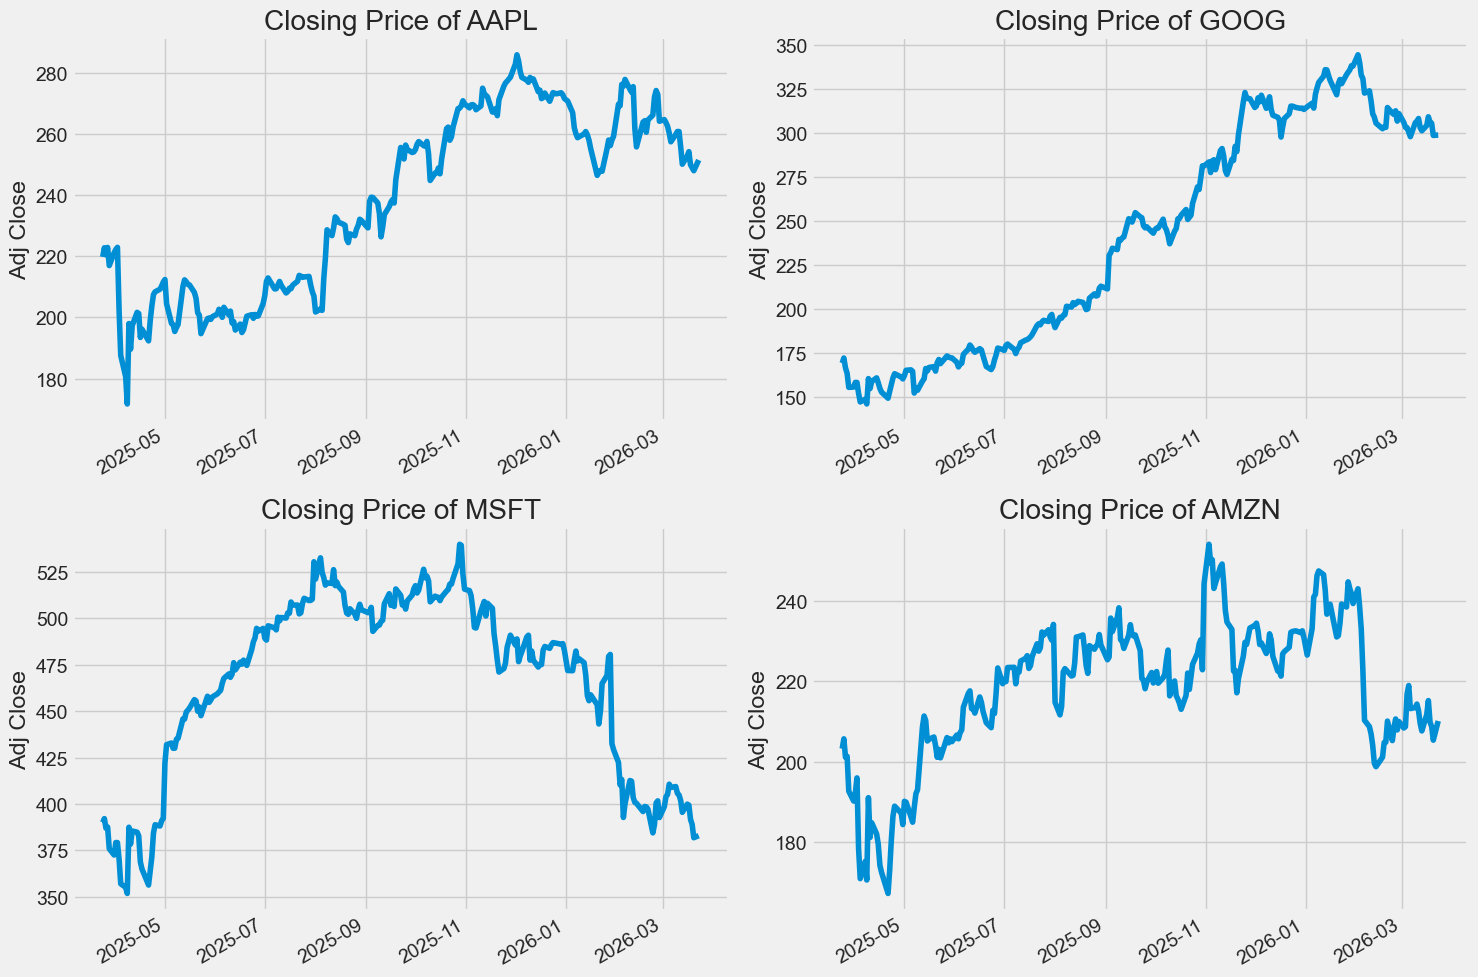

In [10]:
# Let's see a historical view of the closing price
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Adj Close'].plot()
    plt.ylabel('Adj Close')
    plt.xlabel(None)
    plt.title(f"Closing Price of {tech_list[i - 1]}")

plt.tight_layout()

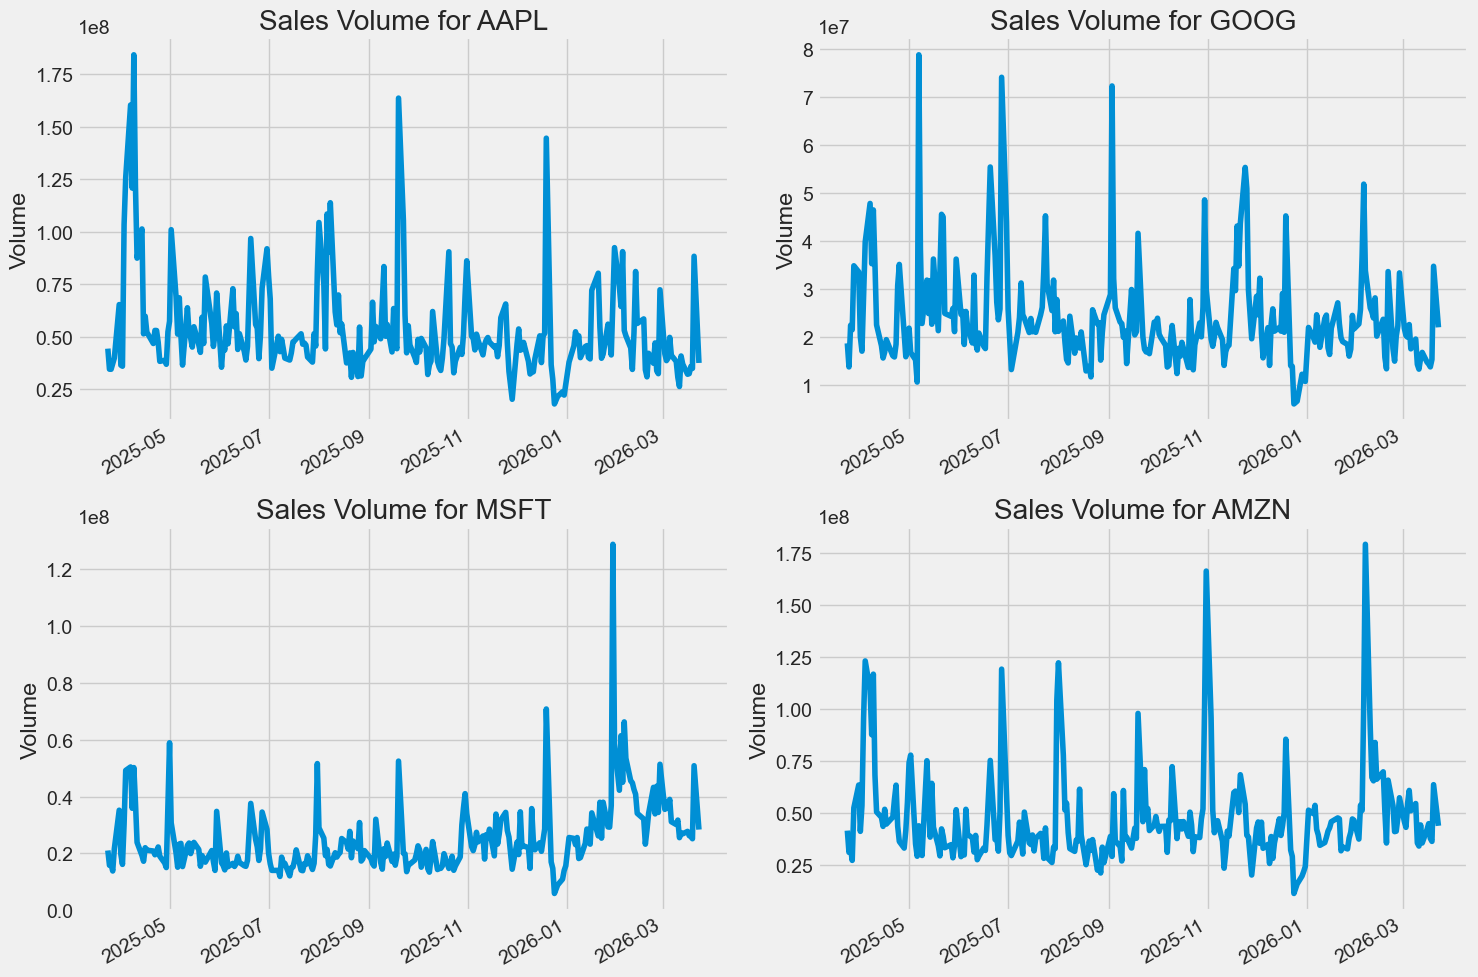

In [11]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")
    
plt.tight_layout()

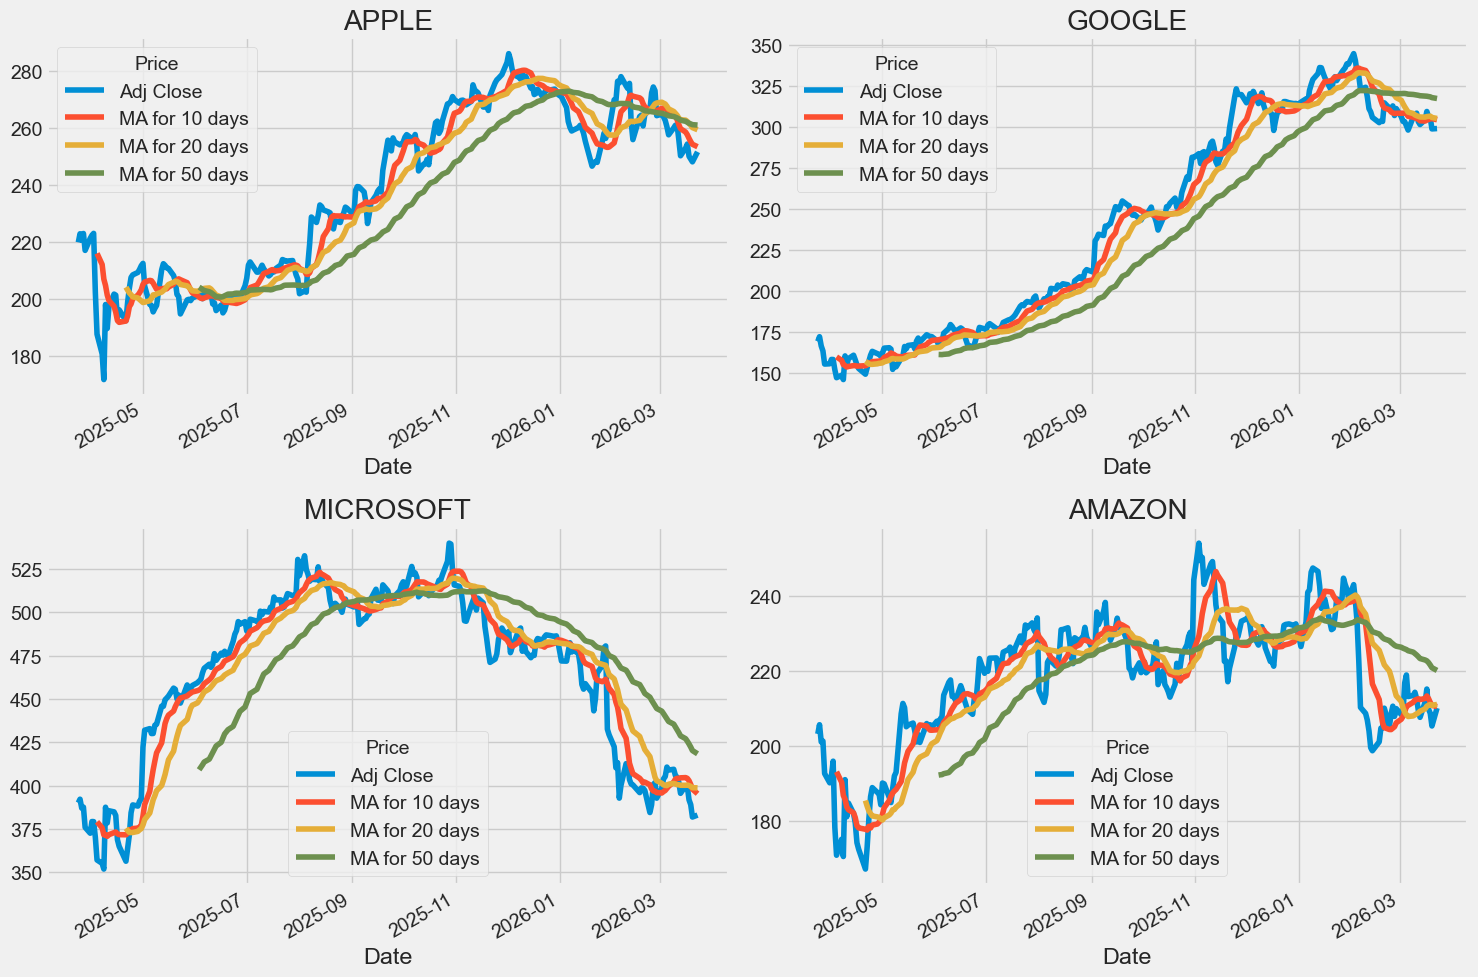

In [12]:
ma_day = [10, 20, 50]

for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Adj Close'].rolling(ma).mean()
        

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

stocks_dict['AAPL'][['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

stocks_dict['GOOG'][['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

stocks_dict['MSFT'][['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

stocks_dict['AMZN'][['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

fig.tight_layout()

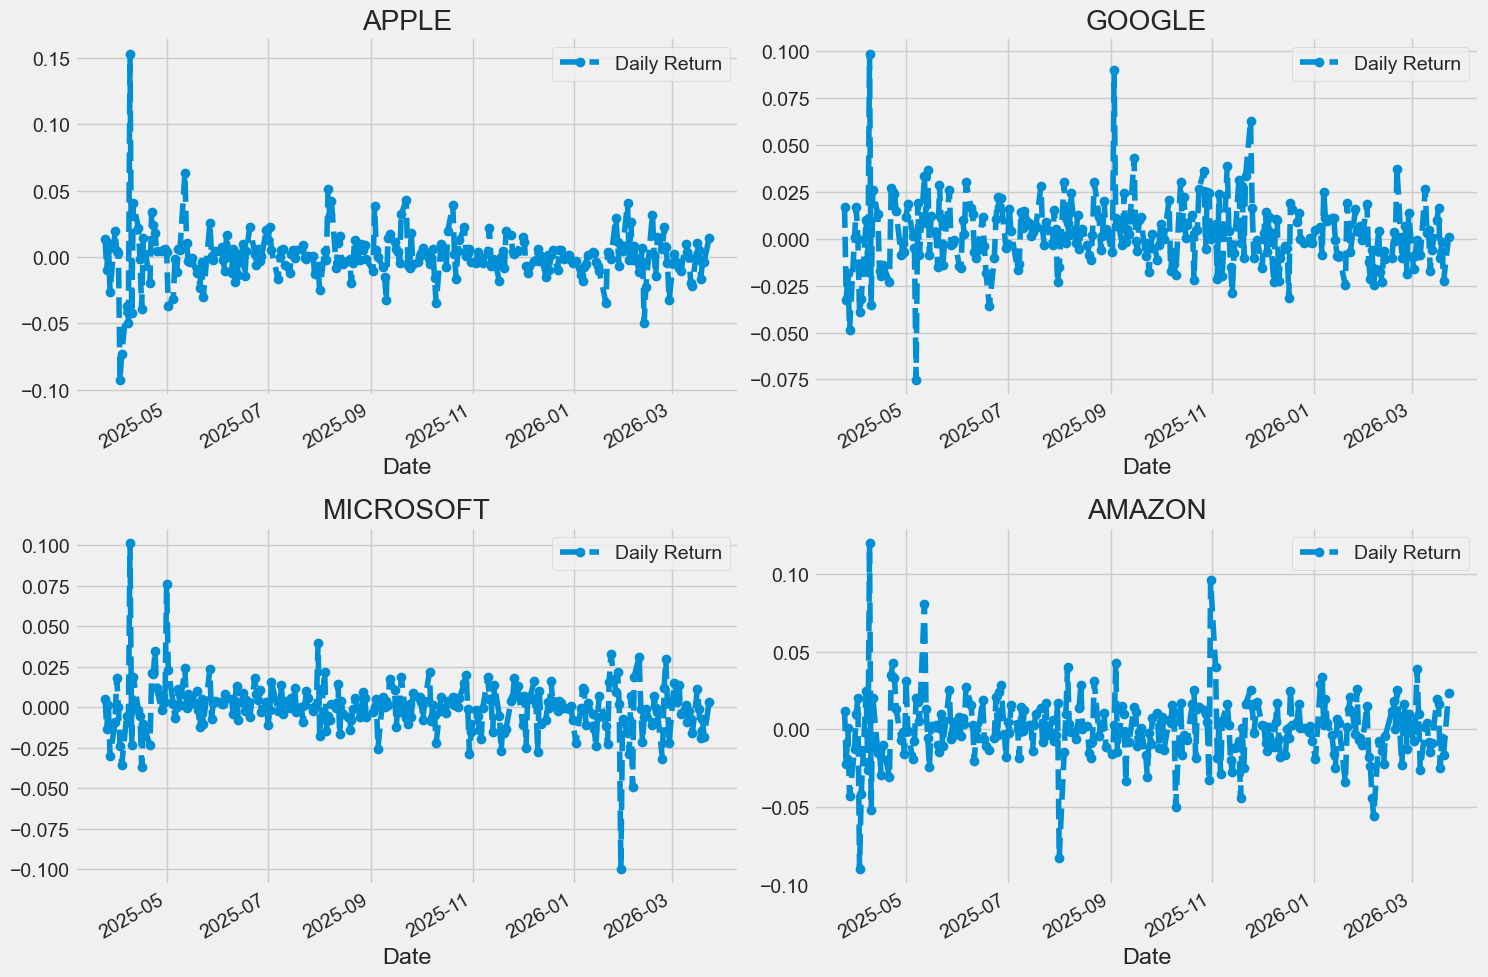

In [13]:
# We'll use pct_change to find the percent change for each day
for company in company_list:
    company['Daily Return'] = company['Adj Close'].pct_change()

# Then we'll plot the daily return percentage
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

stocks_dict['AAPL']['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle='--', marker='o')
axes[0,0].set_title('APPLE')

stocks_dict['GOOG']['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle='--', marker='o')
axes[0,1].set_title('GOOGLE')

stocks_dict['MSFT']['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle='--', marker='o')
axes[1,0].set_title('MICROSOFT')

stocks_dict['AMZN']['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

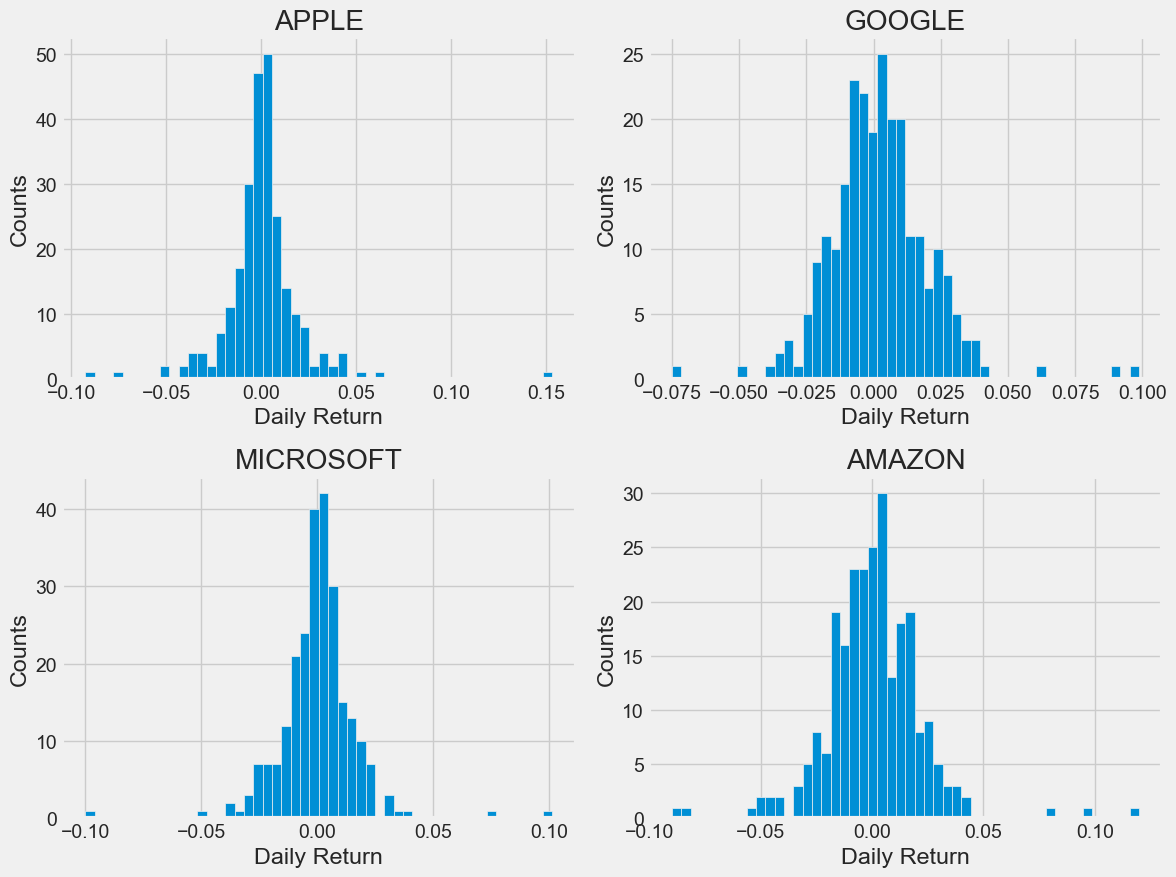

In [14]:
plt.figure(figsize=(12, 9))

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Daily Return'].hist(bins=50)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_name[i - 1]}')
    
plt.tight_layout()

In [15]:
# Grab all the closing prices for the tech stock list into one DataFrame

closing_df = yf.download(tech_list, start=start, end=end, auto_adjust=False)['Adj Close']

# Make a new tech returns DataFrame
tech_rets = closing_df.pct_change()
tech_rets.head(10)

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOG,MSFT
Date,,,,
2025-03-24,NaN,NaN,NaN,NaN
2025-03-25,0.013682,0.012054,0.016830,0.005292
2025-03-26,-0.009922,-0.022264,-0.032699,-0.013134
2025-03-27,0.010473,0.001144,-0.018308,0.001564
2025-03-28,-0.026580,-0.042908,-0.048879,-0.030160
2025-03-31,0.019413,-0.012765,0.001089,-0.009002
2025-04-01,0.004772,0.010039,0.016962,0.018115
2025-04-02,0.003136,0.019982,-0.000126,-0.000131
2025-04-03,-0.092456,-0.089791,-0.039217,-0.023630


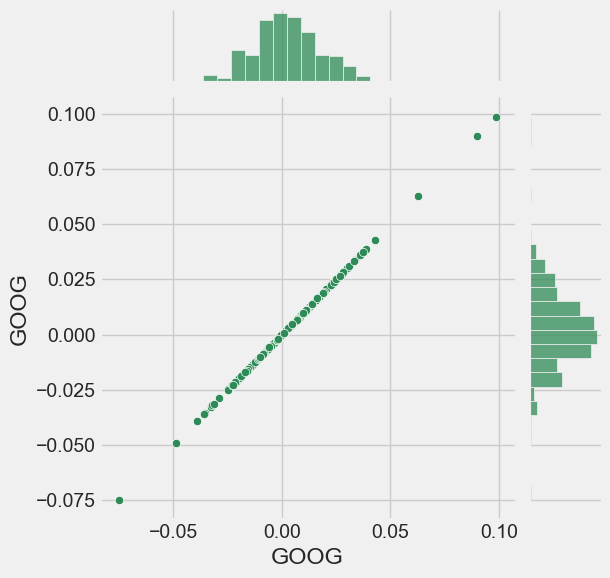

In [16]:
# Comparing Google to itself should show a perfectly linear relationship
sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='seagreen')

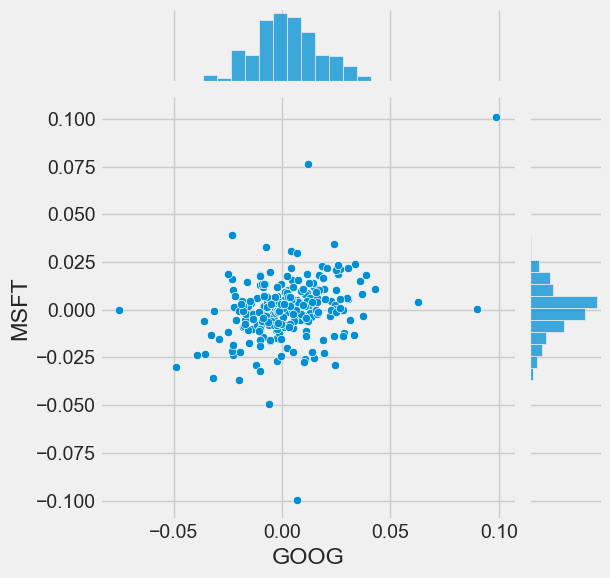

In [17]:
# We'll use joinplot to compare the daily returns of Google and Microsoft
sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter')

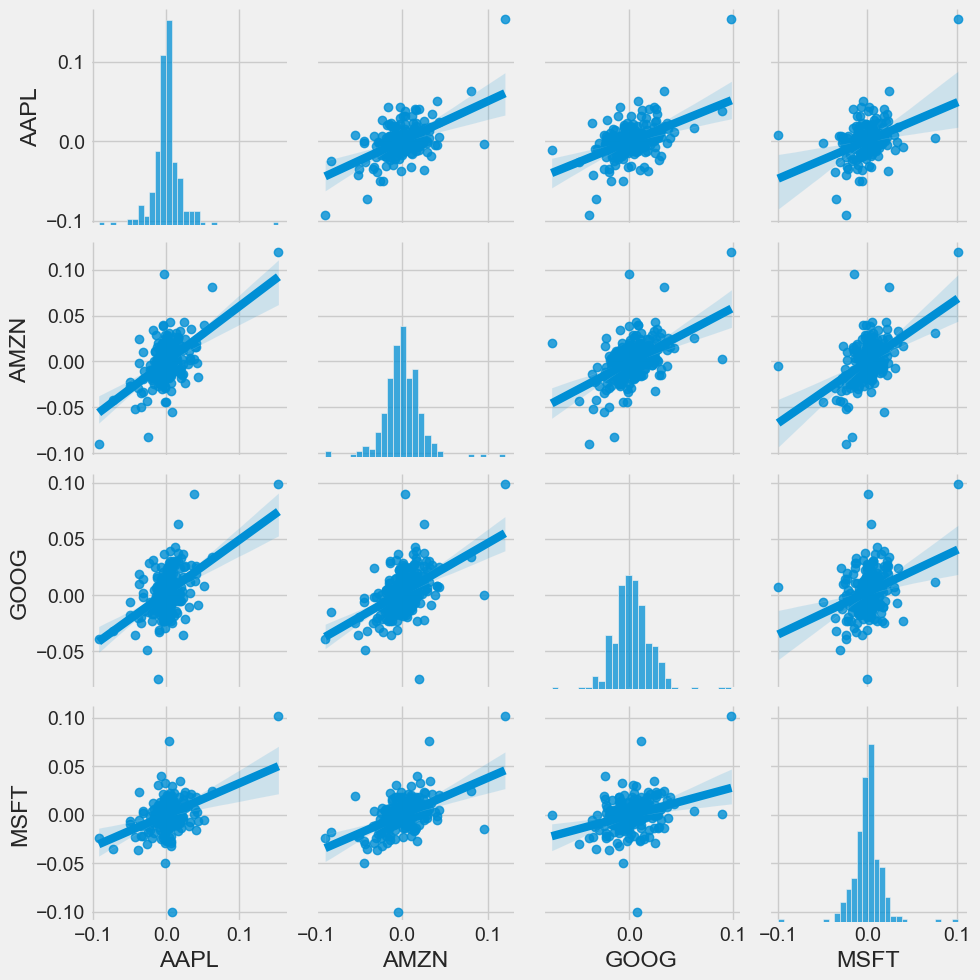

In [18]:
# We can simply call pairplot on our DataFrame for an automatic visual analysis 
# of all the comparisons

sns.pairplot(tech_rets, kind='reg')

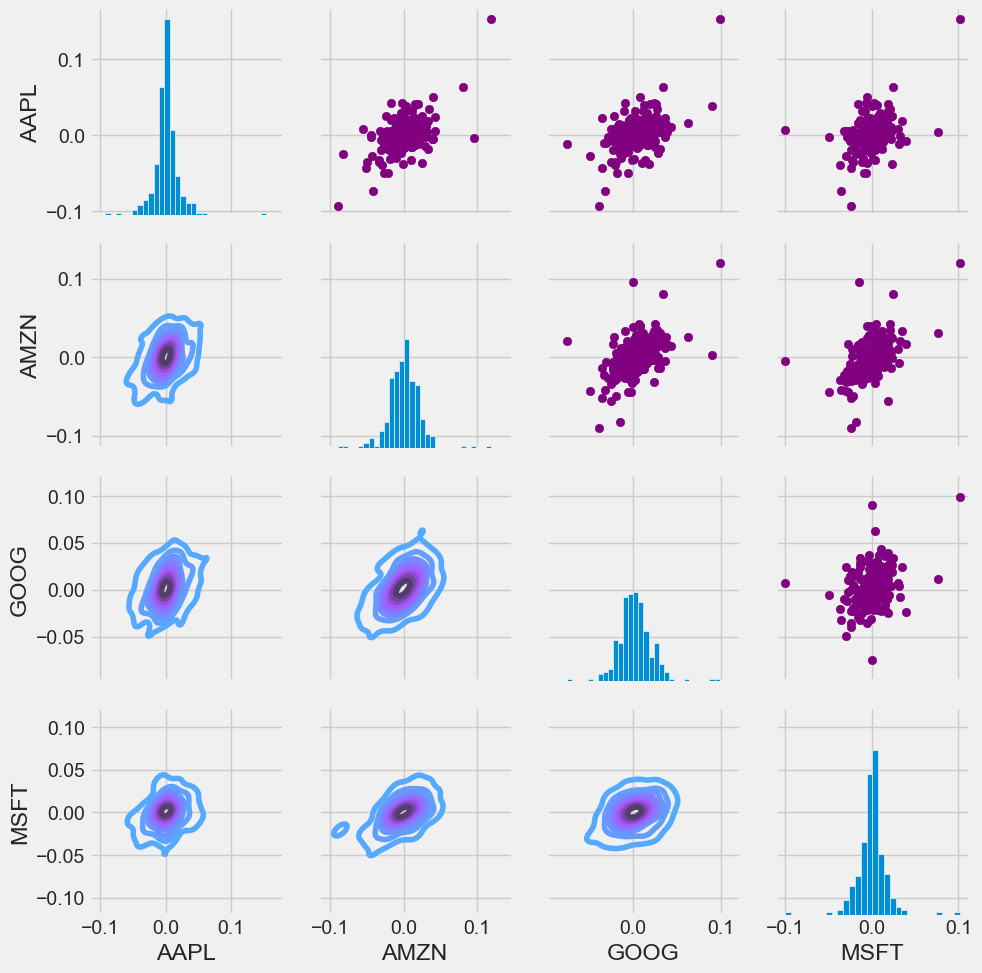

In [19]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(tech_rets.dropna())

# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) 
# or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)

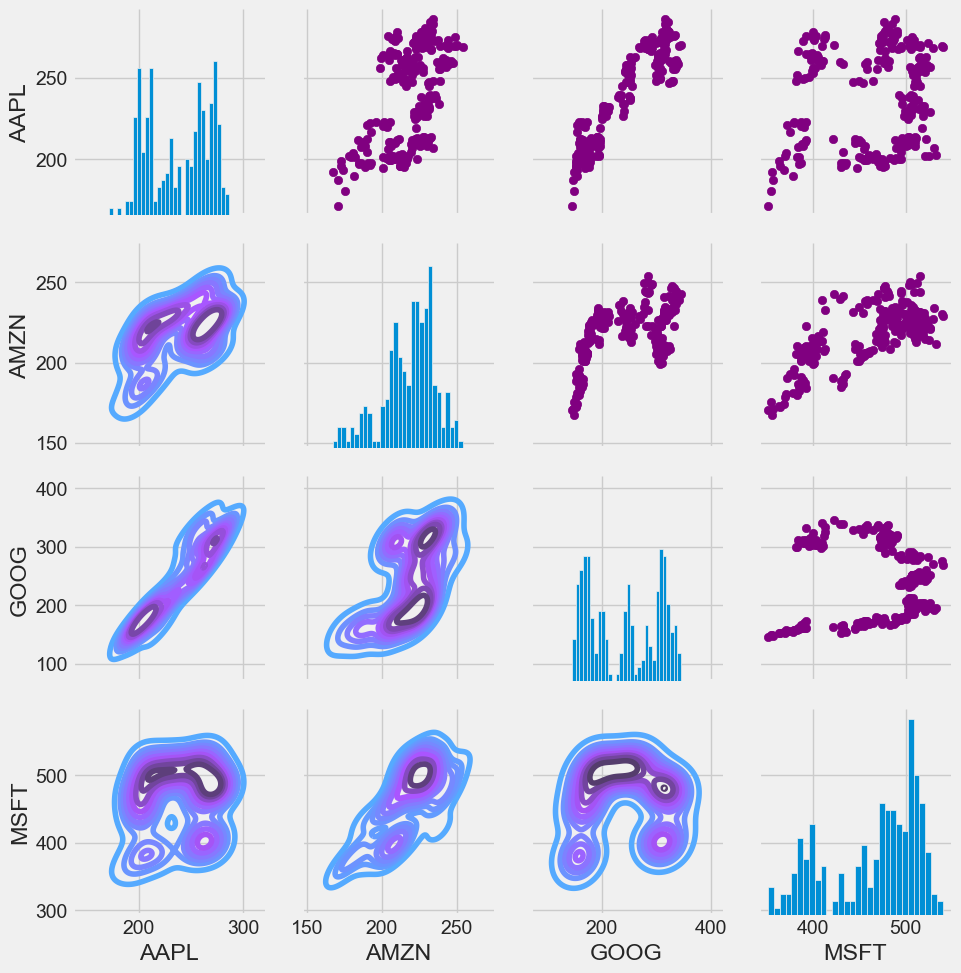

In [20]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
returns_fig = sns.PairGrid(closing_df.dropna())

# Using map_upper we can specify what the upper triangle will look like.
returns_fig.map_upper(plt.scatter,color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) or the color map (BluePurple)
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
returns_fig.map_diag(plt.hist,bins=30)

Text(0.5, 1.0, 'Correlation of stock closing price')

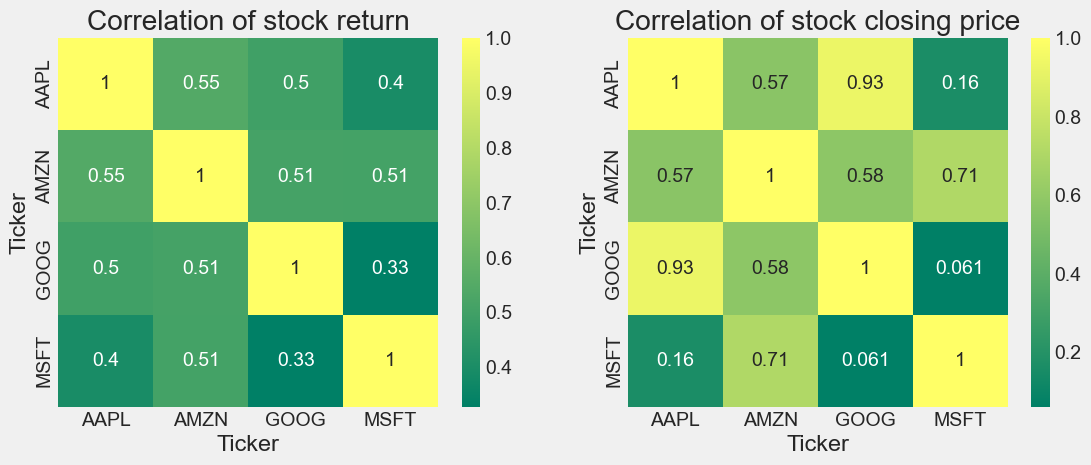

In [21]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

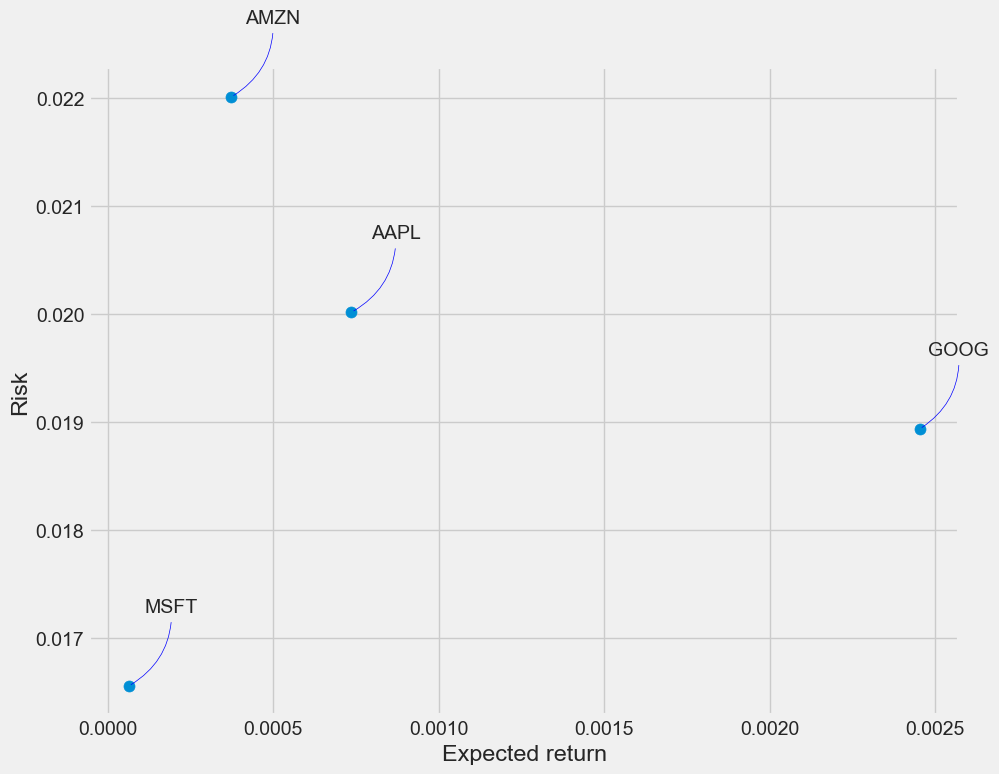

In [22]:
rets = tech_rets.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom', 
    arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

In [23]:
# Get the stock quote
df = yf.download('AAPL', start='2012-01-01', end=datetime.now(), auto_adjust=False)
# Drop Ticker level
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)
# Show teh data
df

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2012-01-03,12.321688,14.686786,14.732143,14.607143,14.621429,302220800
2012-01-04,12.387903,14.765714,14.810000,14.617143,14.642857,260022000
2012-01-05,12.525438,14.929643,14.948214,14.738214,14.819643,271269600
2012-01-06,12.656373,15.085714,15.098214,14.972143,14.991786,318292800
2012-01-09,12.636300,15.061786,15.276786,15.048214,15.196429,394024400
...,...,...,...,...,...,...
2026-03-17,254.229996,254.229996,255.130005,252.179993,252.960007,32361600
2026-03-18,249.940002,249.940002,254.940002,249.000000,252.630005,35757900
2026-03-19,248.960007,248.960007,251.830002,247.300003,249.399994,34864100


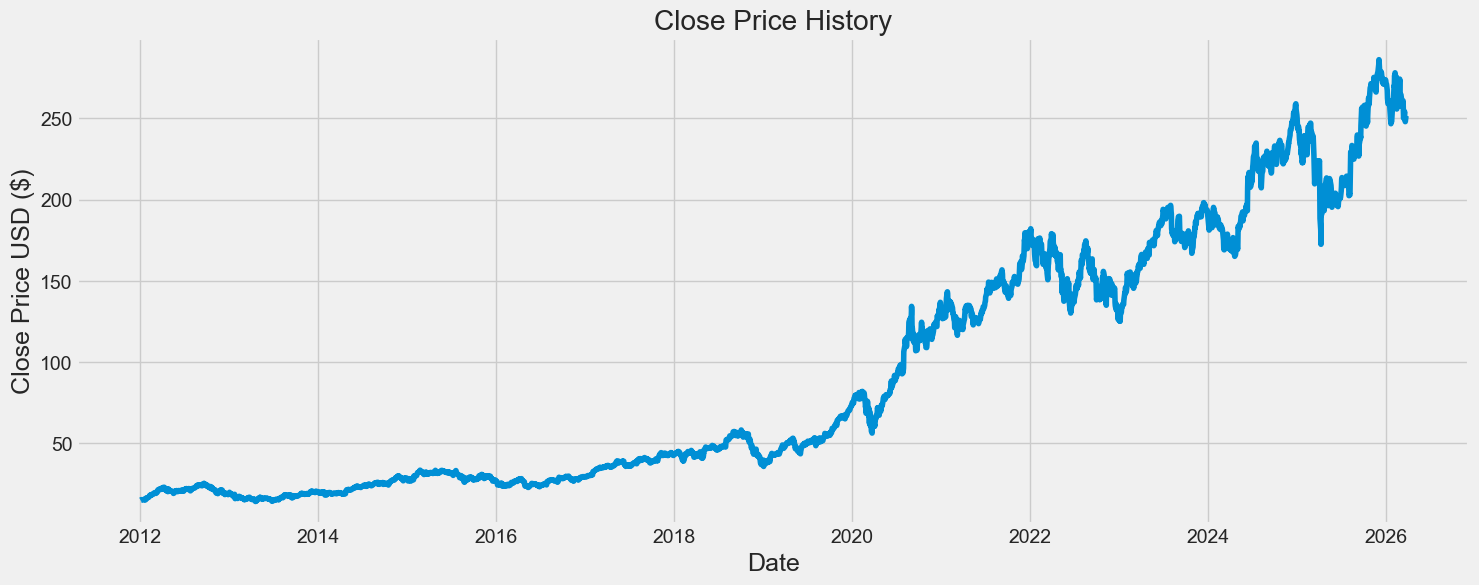

In [24]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [25]:
# Create a new dataframe with only the 'Close' column 
data = df.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

3397

In [26]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00271554],
       [0.00300546],
       [0.0036076 ],
       ...,
       [0.86324694],
       [0.85968393],
       [0.87254012]], shape=(3575, 1))

In [27]:
# Create the training data set 
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.00271554, 0.00300546, 0.0036076 , 0.00418088, 0.00409299,
       0.00429108, 0.00420056, 0.00404838, 0.00384111, 0.00448261,
       0.00506114, 0.00488273, 0.00390539, 0.00483812, 0.00391982,
       0.00736344, 0.00709714, 0.00744478, 0.00819647, 0.00865168,
       0.00861364, 0.00847327, 0.00907148, 0.00963426, 0.01027183,
       0.01130164, 0.01346489, 0.01349768, 0.01470197, 0.0156019 ,
       0.01405522, 0.0146508 , 0.014639  , 0.01630899, 0.01607154,
       0.01651101, 0.01730075, 0.01774023, 0.01900616, 0.01992839,
       0.0201947 , 0.02028785, 0.018711  , 0.01833056, 0.01838697,
       0.01986937, 0.02028654, 0.02118254, 0.02329462, 0.02611249,
       0.02558512, 0.02558643, 0.02762374, 0.02826131, 0.0278074 ,
       0.02739286, 0.02696126, 0.02839511, 0.02937901, 0.02979093])]
[np.float64(0.02877292760128025)]

[array([0.00271554, 0.00300546, 0.0036076 , 0.00418088, 0.00409299,
       0.00429108, 0.00420056, 0.00404838, 0.00384111, 0.00448261,
       0.00506114, 0.00

In [47]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

# Build the LSTM model
model = Sequential()
model.add(Input(shape=(x_train.shape[1], 1))) 
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

3337/3337 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 8.8170e-04


In [48]:
# Create the testing data set
# Create a new array containing scaled values
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


np.float64(7.006024659971168)

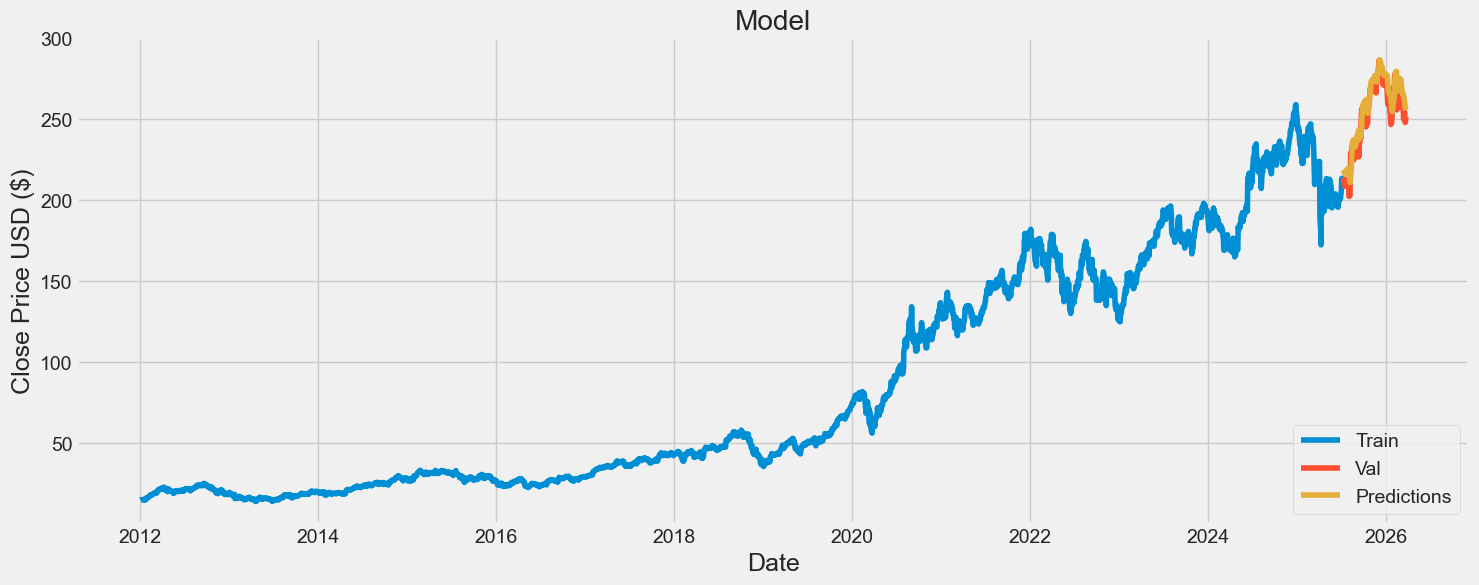

In [49]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [50]:
# Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2025-07-09,211.139999,216.401764
2025-07-10,212.410004,216.722931
2025-07-11,211.160004,217.182312
2025-07-14,208.619995,217.305222
2025-07-15,209.110001,216.728012
...,...,...
2026-03-17,254.229996,260.220581
2026-03-18,249.940002,259.450073
2026-03-19,248.960007,258.196289


In [51]:
import shap

shap.initjs()

In [64]:
# Select background data for SHAP (subset of training data)
background = x_train[:100]  # Using first 100 samples as background

background_numpy = background.numpy() if hasattr(background, 'numpy') else background

# Create SHAP Explainer for the LSTM model
explainer = shap.GradientExplainer(model, background)

# Select a few test samples to explain (e.g., first 5)
test_samples = x_test[:5]

# Compute SHAP values
shap_values = explainer.shap_values(test_samples)